# Annual glacier mass balance estimation from ASTER and MODIS albedo anomalies

Downscale the 20 year glacier mass balance derived from ASTER images (Huggonet et al., 2021, https://doi.org/10.6096/13) to annual glacier mass balance using MODIS glacier-wide albedo anomalies

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping

import glob
import matplotlib.pyplot as plt

import ee
import geemap
ee.Initialize(project='ee-mcallegari')

import glalbedo

## Input definition

Select the RGI (v6.0) id of the glacier and the year for which to estimate the annual glacier mass balance. Set also the mass balance gradient.

In [2]:
# Specify the RGI id of the selected glacier:
rgi60_id = 'RGI60-11.01863'

# Specify the start and end years to generate the annual glacier mass balance time series.
year_start, year_end = 2000, 2024

# Specify the glacier mass balance gradient to be used
db_da = 10.61

Open the RGI shape file containing the selected `rgi60_id`. Look in the `./data/rgi60` folder. RGI v6.0 shape file can be downloaded from https://nsidc.org/data/nsidc-0770/versions/6

,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmin,Zmax,...,Aspect,Lmax,Status,Connect,Form,TermType,Surging,Linkages,Name,geometry
RGIId,,,,,,,,,,,,,,,,,,,,,
RGI60-11.01863,G010629E46434N,20030799,20030999,10.6286,46.4337,11,1,4.151,2663,3717,...,86,3273,0,0,0,0,9,9,None,"POLYGON ((10.62537 46.44609, 10.62536 46.44594..."


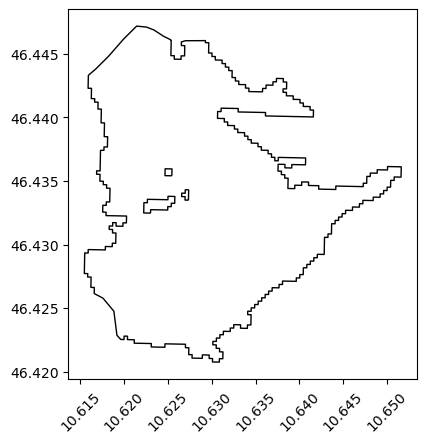

In [3]:
region_code = rgi60_id[6:8]
try:
    rgi_filename = glob.glob(f'./data/rgi60/{region_code}*.shp')[0]
except IndexError:
    raise FileNotFoundError(f"No RGI file available for region code {region_code}")
glacier_outline = gpd.read_file(rgi_filename).set_index('RGIId').loc[[rgi60_id]]
glacier_outline.geometry.plot(color='none')
plt.xticks(rotation=45) 
glacier_outline

## 1) MOD10 albedo processing

Compute the average summer albedo from 2000 to 2019 (i.e. reference period) or until `year_end` if `year_end > 2019`

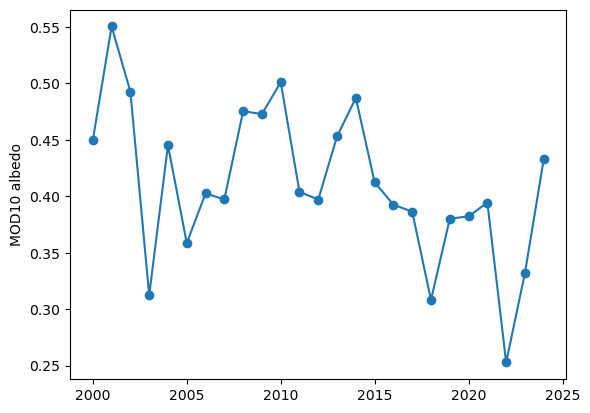

In [4]:
glacier_outline = ee.Geometry(mapping(glacier_outline.loc[rgi60_id].geometry))
        
alb = []
for y in range(2000, max(2019, year_end)+1):
    start_date = f'{y}-05-01'
    end_date = f'{y}-10-31'
    mod_collection = glalbedo.MODalbedo(start_date, end_date, glacier_outline)
    mod_albedo = glalbedo.albedo_ts(mod_collection, glacier_outline, scale=500)
    mod_albedo = glalbedo.albedo_interp(mod_albedo, 0.7)
    alb.append(mod_albedo['albedo_avg_interp'].mean())

MOD10_albedo = pd.Series(index=range(2000, max(2019, year_end)+1), data=alb)
ax = MOD10_albedo.plot(marker='o', ylabel='MOD10 albedo')
ax.xaxis.get_major_locator().set_params(integer=True)

## 2) ASTER mass balance from Hugonnet et al., 2021

Extract the 20 year annual glacier mass balance average (from 2000 to 2019) for the selected glacier from the Hugonnet et al., 2021 dataset (https://doi.org/10.6096/13)

In [5]:
try:
    ASTER_filename = glob.glob(f'./data/Hugonnet2021/dh_{region_code}*.csv')[0]
except IndexError:
    raise FileNotFoundError(f"No Hugonnet file available for region code {region_code}")

ASTER_gmb = pd.read_csv(ASTER_filename, usecols=['rgiid', 'period', 'dmdtda'], index_col=['rgiid', 'period'])
ASTER_gmb = ASTER_gmb.loc[(rgi60_id, '2000-01-01_2020-01-01'), 'dmdtda']
print('20-years annual glacier mass balance average:', ASTER_gmb)

20-years annual glacier mass balance average: -0.723


## 3) Compute the annual mass balance

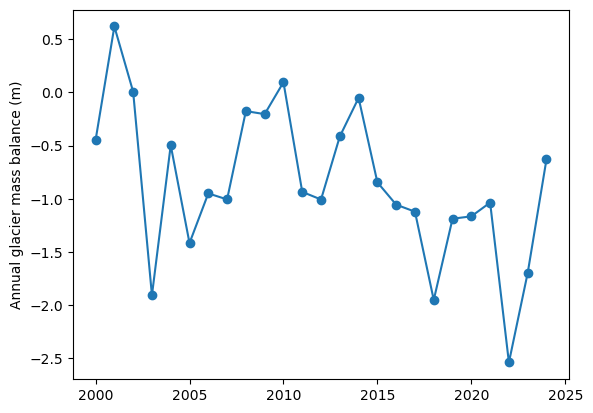

In [6]:
annual_gmb = ASTER_gmb + (MOD10_albedo.loc[year_start:year_end] - MOD10_albedo.loc[2000:2019].mean()) * db_da
ax = annual_gmb.plot(marker='o', ylabel='Annual glacier mass balance (m)')
ax.xaxis.get_major_locator().set_params(integer=True)

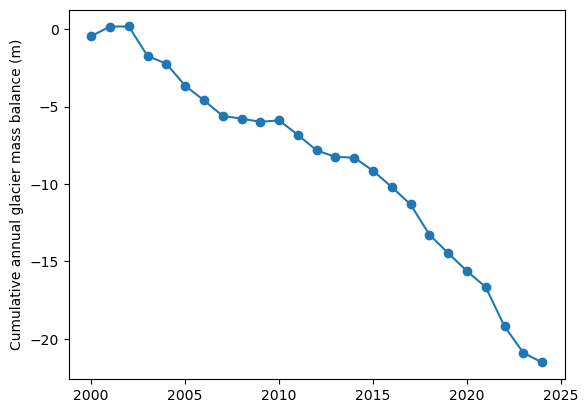

In [7]:
ax = annual_gmb.cumsum().plot(marker='o', ylabel='Cumulative annual glacier mass balance (m)')
ax.xaxis.get_major_locator().set_params(integer=True)